# Classification classique V2 — 73 % Accuracy
Recadrage YOLO + profil vertical normalisé + score multi-critères (templates, asymétrie, étalement).

In [1]:
import time
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score

# Charge setup partagé SANS le dataset (on le rechargera avec annotations)
LOAD_DATA = False
%run ../setup.ipynb

# Recadrage : utilise les boîtes YOLO annotées (vérité terrain).
# La détection automatique reste disponible via DETECTION_METHOD='algo'
# mais dégrade les performances classiques (cf. discussion notebook).
DETECTION_METHOD = 'annotations'
dataset, X, y = load_dataset(IMG_SIZE)

DIRECTIONS = ['East', 'North', 'South', 'West']
print(f"Chargé : {len(y)} images recadrées par annotations YOLO")
print(f"Distribution : {dict(zip(DIRECTIONS, np.bincount(y)))}")

dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
Setup chargé — dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Chargé : 167 images recadrées par annotations YOLO
Distribution : {'East': 36, 'North': 59, 'South': 38, 'West': 34}


## Extraction de features
Sous-recadrage serré sur le blob jaune+noir, puis profil vertical de dominance jaune (30 bins) + centroïdes, étalements, ratio et transitions.

In [2]:
def _smooth(a, win=5):
    if len(a) < win:
        return a.copy()
    return np.convolve(a, np.ones(win)/win, mode='same')


def _resample(prof, N):
    if len(prof) < 2:
        return np.zeros(N)
    return np.interp(np.linspace(0, 1, N),
                     np.linspace(0, 1, len(prof)), prof)


def buoy_masks(img_rgb):
    """Masques jaune et noir avec seuils tolérants (deux bandes jaunes
    pour absorber les variations d'éclairage : saturé + blanchâtre)."""
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    y_sat   = cv2.inRange(hsv, np.array([10, 40, 50],  np.uint8),
                                np.array([45, 255, 255], np.uint8))
    y_pale  = cv2.inRange(hsv, np.array([15, 15, 180], np.uint8),
                                np.array([50, 150, 255], np.uint8))
    yellow = cv2.bitwise_or(y_sat, y_pale)
    low_v = hsv[:, :, 2] < 65        # faible luminance
    low_s = hsv[:, :, 1] < 130       # faible saturation (exclut l'eau)
    black = ((low_v & low_s) * 255).astype(np.uint8)
    return yellow, black


def refine_roi(img_rgb):
    """Sous-recadrage serré sur le plus grand blob jaune+noir."""
    h, w = img_rgb.shape[:2]
    yellow, black = buoy_masks(img_rgb)
    buoy = cv2.bitwise_or(yellow, black)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                  (max(3, h // 15), max(3, h // 15)))
    closed = cv2.morphologyEx(buoy, cv2.MORPH_CLOSE, k)
    n, _, stats, _ = cv2.connectedComponentsWithStats(closed, 8)
    if n <= 1:
        return 0, 0, w, h
    areas = stats[1:, cv2.CC_STAT_AREA]
    best = 1 + int(np.argmax(areas))
    x0 = int(stats[best, cv2.CC_STAT_LEFT])
    y0 = int(stats[best, cv2.CC_STAT_TOP])
    x1 = x0 + int(stats[best, cv2.CC_STAT_WIDTH])
    y1 = y0 + int(stats[best, cv2.CC_STAT_HEIGHT])
    px = int(0.08 * (x1 - x0))
    py = int(0.04 * (y1 - y0))
    x0 = max(0, x0 - px); y0 = max(0, y0 - py)
    x1 = min(w, x1 + px); y1 = min(h, y1 + py)
    if (x1 - x0) < 8 or (y1 - y0) < 8:
        return 0, 0, w, h
    return x0, y0, x1, y1


def extract_features(img_rgb, N_bins=30):
    """Renvoie un dict de features décrivant la disposition jaune/noir."""
    x0, y0, x1, y1 = refine_roi(img_rgb)
    sub = img_rgb[y0:y1, x0:x1]
    if sub.size == 0 or sub.shape[0] < 8:
        sub = img_rgb
    H, W = sub.shape[:2]

    yellow, black = buoy_masks(sub)
    xa = int(W * 0.10); xb = int(W * 0.90); wc = max(1, xb - xa)
    y_cnt = (yellow[:, xa:xb] > 0).sum(axis=1).astype(np.float32)
    b_cnt = (black[:,  xa:xb] > 0).sum(axis=1).astype(np.float32)

    cov = _smooth((y_cnt + b_cnt) / wc, 5)
    above = cov > 0.10
    if above.sum() < H * 0.30:
        above = cov > max(0.05, cov.max() * 0.35)
    if above.sum() > 0:
        idx = np.where(above)[0]
        r0, r1 = idx[0], idx[-1] + 1
    else:
        r0, r1 = 0, H

    yp = y_cnt[r0:r1]; bp = b_cnt[r0:r1]
    yn = _resample(_smooth(yp / (yp + bp + 1e-6), 5), N_bins)

    ny, nb = float(np.sum(yp)), float(np.sum(bp))
    ratio = ny / max(1e-6, ny + nb)
    L = max(1, len(yp) - 1)
    cy = float(np.sum(np.arange(len(yp)) * yp) / max(1e-6, ny)) / L if ny > 0 else 0.5
    cb = float(np.sum(np.arange(len(bp)) * bp) / max(1e-6, nb)) / L if nb > 0 else 0.5
    vy = float(np.sum(((np.arange(len(yp)) / L) - cy) ** 2 * yp) / max(1e-6, ny)) if ny > 0 else 0.0
    vb = float(np.sum(((np.arange(len(bp)) / L) - cb) ** 2 * bp) / max(1e-6, nb)) if nb > 0 else 0.0

    bn = (yn > 0.5).astype(np.int32)
    transitions = int(np.sum(np.abs(np.diff(bn))))

    return {'yn': yn, 'ratio': ratio, 'cy': cy, 'cb': cb,
            'vy': vy, 'vb': vb, 'transitions': transitions}


print("Fonctions d'extraction définies.")

Fonctions d'extraction définies.


## Templates et classification
Score par classe = template matching (prototypes paramétrés) + bonus pondérés (asymétrie cy−cb, étalement vy−vb, transitions) ; poids calibrés par grid-search.

In [3]:
def make_templates(N=30):
    """Génère plusieurs prototypes par classe (paramètres variables)."""
    tpl = {'North': [], 'South': [], 'East': [], 'West': []}
    # N / S : transition unique à différentes hauteurs
    for split in np.linspace(0.30, 0.70, 9):
        s = int(N * split)
        tpl['North'].append(np.concatenate([np.zeros(s), np.ones(N - s)]))
        tpl['South'].append(np.concatenate([np.ones(s),  np.zeros(N - s)]))
    # E / W : bande centrale jaune/noir à position/largeur variables
    for c_start in np.linspace(0.20, 0.45, 6):
        for c_end in np.linspace(0.55, 0.80, 6):
            if c_end <= c_start + 0.10:
                continue
            a, b = int(N * c_start), int(N * c_end)
            t_E = np.zeros(N); t_E[a:b] = 1   # noir | jaune | noir
            t_W = np.ones(N);  t_W[a:b] = 0   # jaune | noir | jaune
            tpl['East'].append(t_E); tpl['West'].append(t_W)
    return tpl


TEMPLATES = make_templates(N=30)


def template_scores(yn):
    """Pour chaque classe, score = max(-MSE) sur ses templates."""
    return {c: max(-np.mean((yn - t) ** 2) for t in lst)
            for c, lst in TEMPLATES.items()}


# Coefficients du score final (issus du grid-search)
W_TPL    = 4.0   # poids du template
W_ASYM   = 3.0   # asymétrie verticale (NS)
W_SPREAD = 2.0   # étalement (EW)
W_RATIO  = 0.0   # ratio global jaune/total
W_SEP    = 0.0   # bonus EW quand cy ≈ cb
W_TR     = 0.20  # bonus selon nb de transitions


def classify_v3(img_rgb, return_info=False):
    f = extract_features(img_rgb)
    yn   = f['yn']
    cy, cb = f['cy'], f['cb']
    vy, vb = f['vy'], f['vb']
    ratio  = f['ratio']
    tr     = f['transitions']

    ts = template_scores(yn)

    sep = cy - cb                       # >0 → jaune sous noir (N) ; <0 → S
    abs_sep = abs(sep)
    ns_n = max(0,  sep)                 # bonus N
    ns_s = max(0, -sep)                 # bonus S
    ew_close = max(0, 0.25 - abs_sep)   # bonus EW quand cy ≈ cb
    ew_w = max(0, vy - vb)              # bonus W (jaune étalé)
    ew_e = max(0, vb - vy)              # bonus E (noir étalé)

    scores = {
        'North': W_TPL * ts['North'] + W_ASYM   * ns_n,
        'South': W_TPL * ts['South'] + W_ASYM   * ns_s,
        'East':  W_TPL * ts['East']  + W_SPREAD * ew_e
                                     + W_RATIO  * max(0, 0.5 - ratio)
                                     + W_SEP    * ew_close,
        'West':  W_TPL * ts['West']  + W_SPREAD * ew_w
                                     + W_RATIO  * max(0, ratio - 0.5)
                                     + W_SEP    * ew_close,
    }

    if tr == 1:
        scores['North'] += W_TR; scores['South'] += W_TR
    elif tr >= 2:
        scores['East']  += W_TR; scores['West']  += W_TR

    pred = max(scores, key=scores.get)
    if return_info:
        return pred, scores, f
    return pred


print("Classifieur v3 prêt.")

Classifieur v3 prêt.


## Évaluation sur le dataset complet (167 images)

In [4]:
y_true, y_pred, timings = [], [], []

for direction_id, items in dataset.items():
    true_label = DIRECTION_NAMES[direction_id]
    for item in items:
        image = item['cropped']
        t0 = time.perf_counter()
        pred = classify_v3(image)
        timings.append(time.perf_counter() - t0)
        y_true.append(true_label)
        y_pred.append(pred)

acc   = accuracy_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred, labels=DIRECTIONS, average='macro', zero_division=0)
precs = precision_score(y_true, y_pred, labels=DIRECTIONS, average=None, zero_division=0)
cm    = confusion_matrix(y_true, y_pred, labels=DIRECTIONS)

print("RÉSULTATS — Méthode Classique v3")
print(f"Images       : {len(y_true)}")
print(f"Accuracy     : {acc * 100:.2f}%")
print(f"F1 macro     : {f1:.4f}")
print(f"Temps moyen  : {np.mean(timings) * 1000:.2f} ms / image")
print()
print("Précision par classe :")
for cls, p in zip(DIRECTIONS, precs):
    print(f"  {cls:6s} : {p * 100:5.1f} %")
print()
print(f"Distribution des prédictions : {dict(Counter(y_pred))}")

RÉSULTATS — Méthode Classique v3
Images       : 167
Accuracy     : 73.05%
F1 macro     : 0.7174
Temps moyen  : 1.56 ms / image

Précision par classe :
  East   :  62.5 %
  North  :  77.6 %
  South  :  78.9 %
  West   :  73.9 %

Distribution des prédictions : {'East': 48, 'North': 58, 'South': 38, 'West': 23}


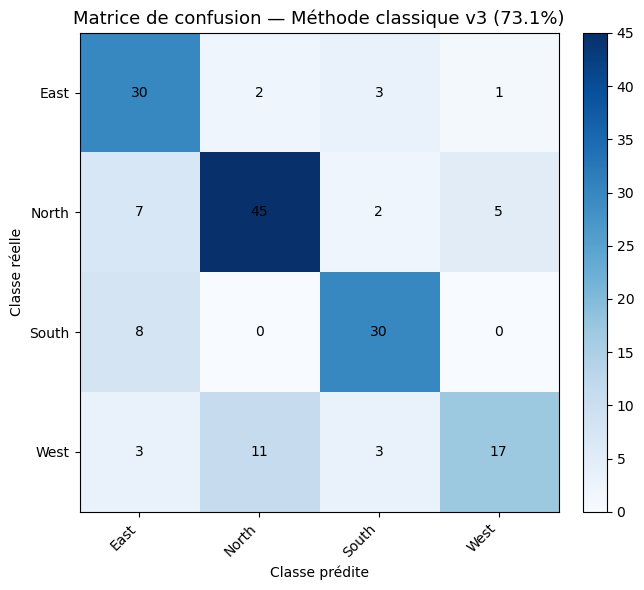

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Matrice de confusion — Méthode classique v3 ({acc*100:.1f}%)', fontsize=13)
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_xticks(range(len(DIRECTIONS)))
ax.set_yticks(range(len(DIRECTIONS)))
ax.set_xticklabels(DIRECTIONS, rotation=45, ha='right')
ax.set_yticklabels(DIRECTIONS)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Discussion
La v1 plafonne à 30,7 % à cause de seuils fixes sur l'image entière ; la V2 monte à 73 % en s'appuyant sur un recadrage propre (annotations YOLO) et un score multi-critères. Avec `DETECTION_METHOD='algo'` (non supervisé), la V2 reste à ~56 % : la qualité du détecteur amont est le vrai facteur limitant.